# Analysing Company ESG performance - Data preparation 

## Objectives



## Inputs

* An exported CSV file (public_company_esg_ratings_cleaned.csv) 

The dataset for this project was downloaded from Kaggle: https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset



## Outputs



## Additional Comments






# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir 

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis\\jupyter_notebooks'

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis'

# Import project dependencies and data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv("data/public_company_esg_ratings_cleaned.csv")

In [7]:
df.head()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level,environment_score_norm,social_score_norm,governance_score_norm
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,BBB,High,0.60,0.31,0.62
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,BBB,High,0.60,0.28,0.45
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,BB,Medium,0.11,0.44,0.41
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,BBB,High,0.71,0.27,0.57
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,BBB,High,0.56,0.30,0.44


# Exploring the data through visualisations 

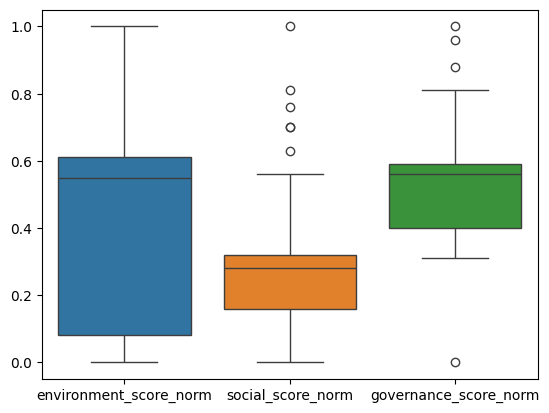

In [ ]:
sns.boxplot(data=df[["environment_score_norm", "social_score_norm", "governance_score_norm"]])
plt.title("Average Normalised ESG Pillar Scores by Industry", fontsize=14, fontweight="bold")
plt.show()

## Pillar comparison: raw scores vs. normalised scores

Creating a new version of the boxplot we used to show the outliers in the original dataset again with the normalised version shows a clear differenece in the balance between the ESG pillars. 

The initial inspection of raw pillar score means (environment_score ≈405, social_score ≈292, governance_score ≈279) suggested a fairly smooth, proportional decline across the three pillars. Environment being the highest, followed by Social in the middle and Governance being the lowest. No one pillar stood out as dramatically different from the others.

Using the normalised scores changes the picture. The Environment (median ≈0.55) and Governance (median ≈0.56) pillars remain in very similar positions, but the Social (median ≈0.27) now sits meaningfully lower — roughly half the level of the other two pillars. This shows why normalisation was a necessary step before drawing conclusions: Governance was never genuinely behind Environment — it simply operated on a smaller numeric range. The real gap is between Social and the other two pillars.

### Reflection: is Social's lower performance surprising?

This result initially seemed counter-intuitive to me. I had assumed from my own experience interviewing stakeholders from businesses opertaing in the USA that social initiatives such as DEI and inclusive hiring policies are often faster and easier for companies to implement than environmental or governance reforms (which can require substantial structural or long-term investment). 

BUT...

The Social pillar in this rating likely covers far more than DEI alone. It potentially includes labour practices, supply chain human rights, product safety, and data privacy. It is also worth restating that this dataset does not disclose its rating methodology. It's possible the Social criteria are simply scored on a stricter basis than Environment or Governance, independent of actual company performance.
It could also be the case that social policies like wellbeing initiatives may be easier to announce than to substantiate under third-party scrutiny.

Without visibility into the rating agency's methodology, it isn't possible to say which explanation (or combination) is correct from this dataset alone.

## Comparing different industries 

To move from an overall pillar comparison to a more focused industry-level view, I calculated the average normalised pillar scores per industry using groupby("industry"). Before this comparison could be considered reliable, industry sample sizes were checked using .value_counts(). This showed that there is a  a highly uneven distribution — ranging from 63 companies in Technology down to just 2 in Tobacco. The dataset had a natural three-tier structure with a handful of large industries, a mid-sized cluster and a long tail of small ones.

Since averaging scores across a group with only 2-3 companies would not produce a statistically meaningful comparison, I applied a minimum threshold of 10 companies per industry. This reduced the dataset from 44 to 23 industries. This cutoff was chosen deliberately at a natural gap in the company-count distribution rather than an arbitrary round number. The "Unknown" industry category (companies with missing industry data) was also explicitly excluded at this stage. This was not for statistical reasons, since it exceeded the count threshold. It was because it does not represent a comparable industry.

The resulting 23-industry averages were visualised using a horizontal grouped bar chart, with one bar per pillar per industry. A horizontal orientation was used to accommodate the number of industries and their label lengths more readably than a vertical layout. An overlapping-bar variant was also tested for comparison, but the grouped (side-by-side) version proved clearer. Since Environment and Governance scores are frequently close in value across industries, making an overlapping layout harder to make sense of visually.



In [7]:
df['industry'].unique()

array(['Media', 'Automobiles', 'Trading Companies and Distributors',
       'Consumer products', 'Hotels Restaurants and Leisure',
       'Diversified Consumer Services', 'Airlines', 'Insurance',
       'Communications', 'Building', 'Technology', 'Electrical Equipment',
       'Logistics and Transportation', 'Unknown', 'Biotechnology',
       'Health Care', 'Life Sciences Tools and Services', 'Banking',
       'Semiconductors', 'Pharmaceuticals', 'Financial Services',
       'Commercial Services and Supplies', 'Chemicals', 'Real Estate',
       'Utilities', 'Machinery', 'Food Products', 'Retail', 'Energy',
       'Road and Rail', 'Distributors', 'Beverages', 'Telecommunication',
       'Professional Services', 'Auto Components', 'Packaging',
       'Aerospace and Defense', 'Tobacco', 'Metals and Mining',
       'Construction', 'Textiles Apparel and Luxury Goods',
       'Industrial Conglomerates', 'Leisure Products', 'Marine'],
      dtype=object)

In [9]:
industry_counts = df['industry'].value_counts()
print(industry_counts)

industry
Technology                            63
Biotechnology                         56
Health Care                           51
Real Estate                           36
Financial Services                    33
Utilities                             30
Banking                               29
Electrical Equipment                  27
Insurance                             27
Retail                                26
Semiconductors                        24
Hotels Restaurants and Leisure        24
Media                                 23
Machinery                             21
Pharmaceuticals                       21
Energy                                21
Consumer products                     20
Chemicals                             19
Life Sciences Tools and Services      16
Food Products                         14
Unknown                               13
Aerospace and Defense                 11
Building                              10
Metals and Mining                     10
Textile

In [10]:
df.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean().round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Airlines,0.24,0.21,0.43
Auto Components,0.27,0.17,0.43
Automobiles,0.37,0.14,0.40
Banking,0.27,0.26,0.47
Beverages,0.53,0.28,0.53
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54


In [11]:
valid_industries = industry_counts[industry_counts >= 10].index

df_filtered = df[(df["industry"].isin(valid_industries)) & (df["industry"] != "Unknown")]

df_filtered["industry"].nunique()

23

In [12]:
industry_pillar_avg = df_filtered.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean()
industry_pillar_avg.round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Banking,0.27,0.26,0.47
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54
Consumer products,0.36,0.25,0.50
Electrical Equipment,0.35,0.22,0.51
Energy,0.61,0.29,0.55
Financial Services,0.32,0.23,0.48


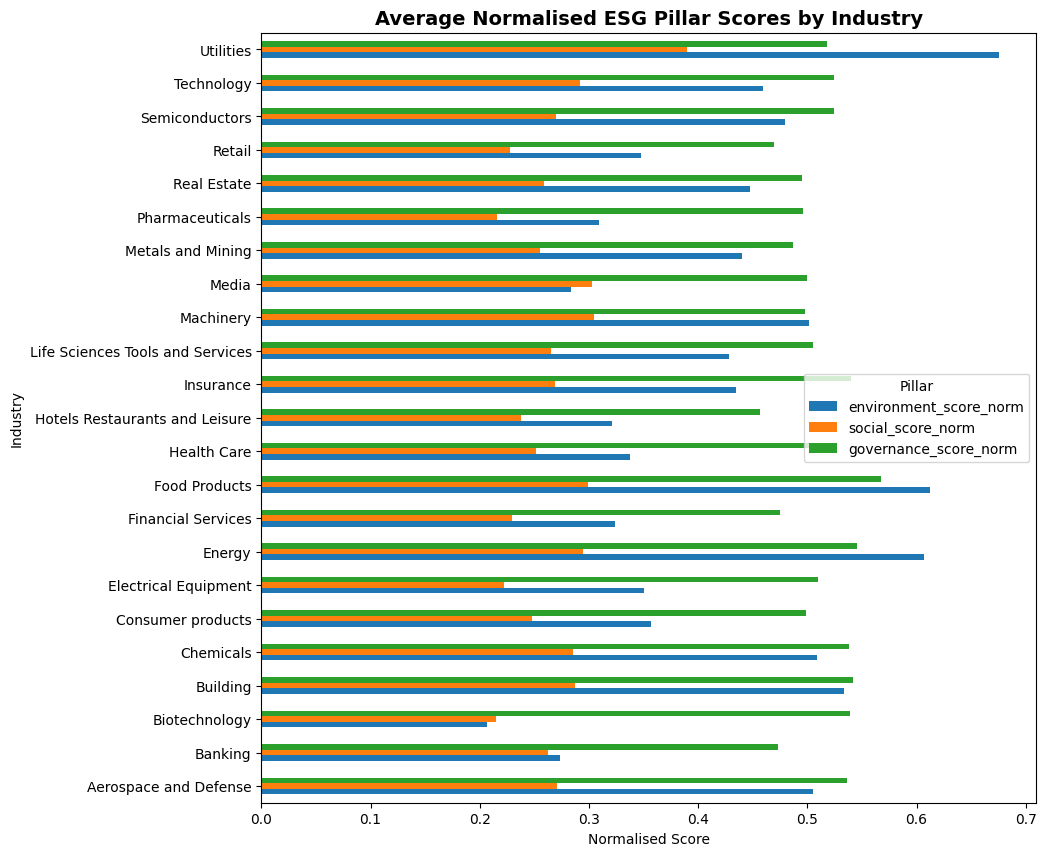

In [13]:
industry_pillar_avg.plot(kind="barh", figsize=(10, 10))
plt.title("Average Normalised ESG Pillar Scores by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Normalised Score")
plt.ylabel("Industry")
plt.legend(title="Pillar")
plt.show()

In [14]:
industry_pillar_avg.idxmax(axis=1)

industry
Aerospace and Defense                governance_score_norm
Banking                              governance_score_norm
Biotechnology                        governance_score_norm
Building                             governance_score_norm
Chemicals                            governance_score_norm
Consumer products                    governance_score_norm
Electrical Equipment                 governance_score_norm
Energy                              environment_score_norm
Financial Services                   governance_score_norm
Food Products                       environment_score_norm
Health Care                          governance_score_norm
Hotels Restaurants and Leisure       governance_score_norm
Insurance                            governance_score_norm
Life Sciences Tools and Services     governance_score_norm
Machinery                           environment_score_norm
Media                                governance_score_norm
Metals and Mining                    governance

In [15]:
industry_pillar_avg.idxmin(axis=1)

industry
Aerospace and Defense                    social_score_norm
Banking                                  social_score_norm
Biotechnology                       environment_score_norm
Building                                 social_score_norm
Chemicals                                social_score_norm
Consumer products                        social_score_norm
Electrical Equipment                     social_score_norm
Energy                                   social_score_norm
Financial Services                       social_score_norm
Food Products                            social_score_norm
Health Care                              social_score_norm
Hotels Restaurants and Leisure           social_score_norm
Insurance                                social_score_norm
Life Sciences Tools and Services         social_score_norm
Machinery                                social_score_norm
Media                               environment_score_norm
Metals and Mining                        social

In [ ]:
lowest_pillar_counts = industry_pillar_avg.idxmin(axis=1).value_counts()
highest_pillar_counts = industry_pillar_avg.idxmax(axis=1).value_counts()

print(flowest_pillar_counts)
print(highest_pillar_counts)

social_score_norm         21
environment_score_norm     2
Name: count, dtype: int64
governance_score_norm     19
environment_score_norm     4
Name: count, dtype: int64


### Key finding: consistent Social pillar underperformance across industries

My initial visual inspection of the chart suggested that the Social pillar scored lowest in nearly every industry, with Governance most frequently the highest-scoring pillar. I decided to verify this using .idxmin(axis=1) and .idxmax(axis=1) to identify the lowest- and highest-scoring pillar for each individual industry row. It's a good thing I did, because my visual inspection had totally missed the Machinery industry also having a higher environmental score then governance.

I confirmed that Social is the lowest-scoring pillar for 21 of 23 industries — only Biotechnology and Media breaking the pattern. Governance was the highest-scoring pillar in 14 of 23 industries, with Environment being the highest scoring pillar in four specific industries: Food Products, Utilities, Energy, and Machinery. I believe this is likely explained by these sectors' direct environmental impact and regulatory exposure compared to other sectors like Banking or Insurance.

This represents strong evidence of the pillar imbalance this project set out to investigate. Rather than being random or industry-specific, the performance imbalance across ESG pillars follows a consistent structural pattern of Social lagging almost universally.